In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>CUP - SVM</h1>
<p>Exploring the cup dataset with SVM Classifier.</p>
<hr/>

In [2]:
import importlib

import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, \
    r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict, KFold
import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [4]:
# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = {
    "model__estimator__kernel": ["rbf", "linear", "poly"],
    "model__estimator__C": [0.1, 1, 10, 100],
    "model__estimator__gamma": ["scale", 0.1, 0.01, 0.001],
    "model__estimator__epsilon": [0.01, 0.05, 0.1, 0.2],
    "model__estimator__degree": [2, 3, 4],
}

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(SVR()))
])

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,min),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------

# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [5]:
df_train, df_test = cc.load_set()
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)
features_names = X_tr.columns
cr.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,15,11
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [6]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h3>Best Model</h3>

In [7]:
# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
gs.fit(X_tr, y_tr)
best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)
cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 576  splits: 5
Best params: {'model__estimator__C': 100, 'model__estimator__degree': 2, 'model__estimator__epsilon': 0.2, 'model__estimator__gamma': 0.1, 'model__estimator__kernel': 'rbf'}
Best score: -23.265419603565288
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100, degree=2,
                                                    epsilon=0.2, gamma=0.1)))])


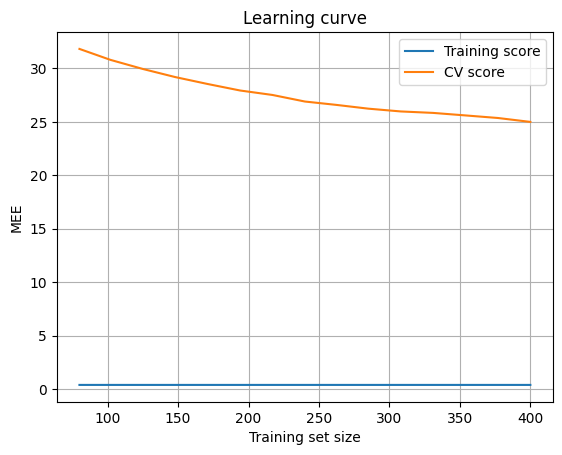

In [8]:
importlib.reload(cr)
cr.plot_learning_curve(best_model, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [9]:
from sklearn import clone

non_nested_runner = cr.SklearnRegressorRunner(clone(gs.best_estimator_).set_params(**gs.best_params_))
non_nested_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv,metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 23.9849
Validation mse       | 201.8393
Validation mae       | 10.6716
Validation rmse      | 14.2070
Validation r2        | 0.3867
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 23.4815
Validation mse       | 181.5517
Validation mae       | 10.3959
Validation rmse      | 13.4741
Validation r2        | 0.4137
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 3, train size: 400, val size: 100
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 23.4375
Validation mse       | 177.0136
Validation mae       | 10.5129
Validation 

In [10]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -23.2654 ± 1.0531
Best CV func score: 23.2654 ± 1.0531


<h3>Nested Cross Validation</h3>

In [11]:
importlib.reload(cr)

inner_cv = cr.common_fold_strategy(n_split=3)
outer_cv = outer_cv

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics_dict)

  
Perform fold: 1, train size: 400, val size: 100
Grid summary
----------------------------------------
Total model explored: 576  splits: 3
Best params: {'model__estimator__C': 100, 'model__estimator__degree': 2, 'model__estimator__epsilon': 0.2, 'model__estimator__gamma': 0.1, 'model__estimator__kernel': 'rbf'}
Best score: -23.06046573813572
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=100, degree=2,
                                                    epsilon=0.2, gamma=0.1)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation mee       | 23.9849
Validation mse       | 201.8393
Validation mae       | 10.6716
Validation rmse      | 14.2070
Validation r2        | 0.3867
Train                | samples: 400
Validation           | samples: 100
  
Perform fold: 2, train size: 400, val size: 100
Grid summary
---------------------------------

<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

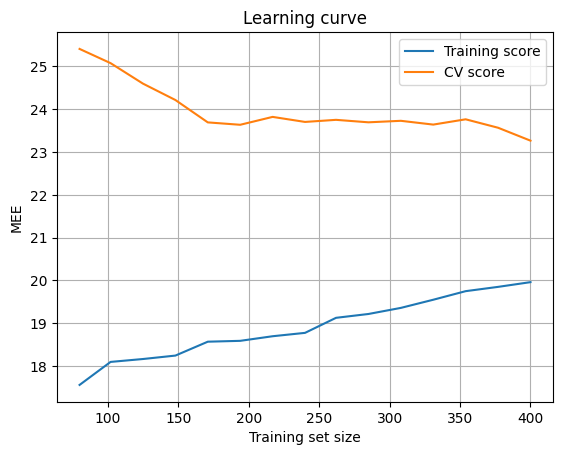

In [12]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=gs.scoring)

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

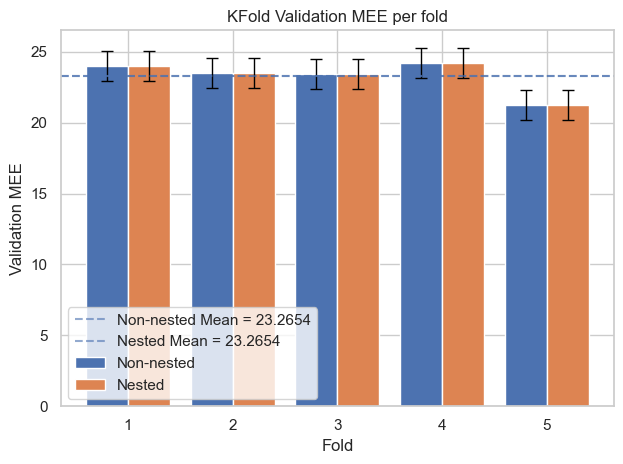

mee TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,19.773098,23.984907,4.211809,21.30%
2,20.125868,23.481511,3.355644,16.67%
3,19.888241,23.437497,3.549255,17.85%
4,19.648648,24.184218,4.535571,23.08%
5,20.367172,21.238965,0.871793,4.28%
MEAN,19.960605,23.265420,3.304814,16.64%
STD,0.287368,1.177357,1.442162,7.37%


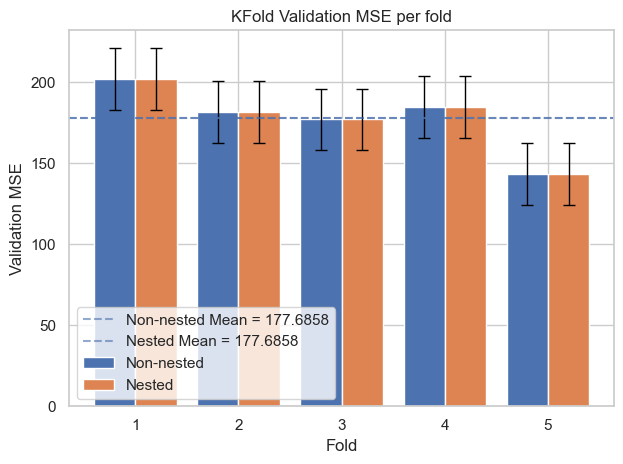

mse TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,133.434562,201.839273,68.404711,51.26%
2,139.245236,181.551718,42.306482,30.38%
3,138.921883,177.013582,38.091699,27.42%
4,134.771853,184.546669,49.774816,36.93%
5,143.833448,143.477800,-0.355649,0.25%
MEAN,138.041396,177.685808,39.644412,29.25%
STD,4.113551,21.307547,25.195646,18.63%


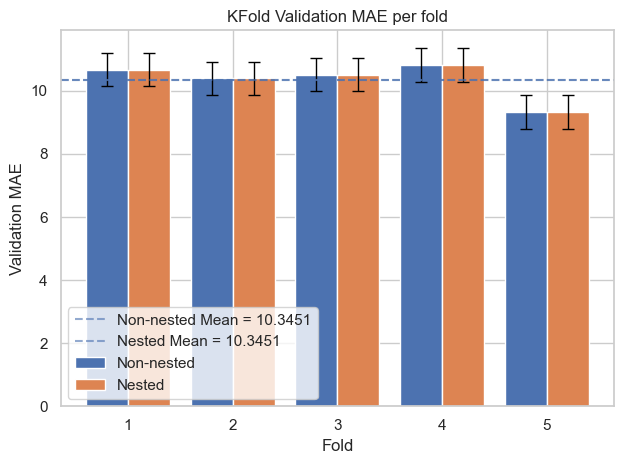

mae TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,8.525296,10.671556,2.146260,25.18%
2,8.716743,10.395856,1.679113,19.26%
3,8.580947,10.512927,1.931980,22.51%
4,8.407358,10.820211,2.412853,28.70%
5,8.850627,9.324739,0.474112,5.36%
MEAN,8.616194,10.345058,1.728864,20.20%
STD,0.171891,0.592491,0.751697,8.99%


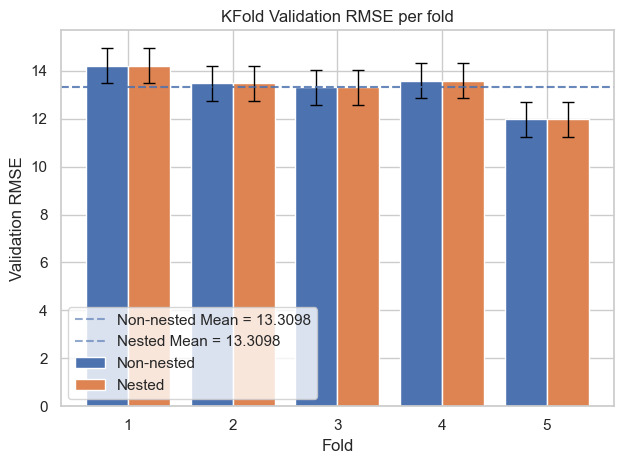

rmse TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,11.551388,14.207015,2.655627,22.99%
2,11.800222,13.474113,1.673891,14.19%
3,11.786513,13.304645,1.518132,12.88%
4,11.609128,13.584796,1.975667,17.02%
5,11.993058,11.978222,-0.014836,0.12%
MEAN,11.748062,13.309758,1.561696,13.44%
STD,0.174790,0.818649,0.983361,8.40%


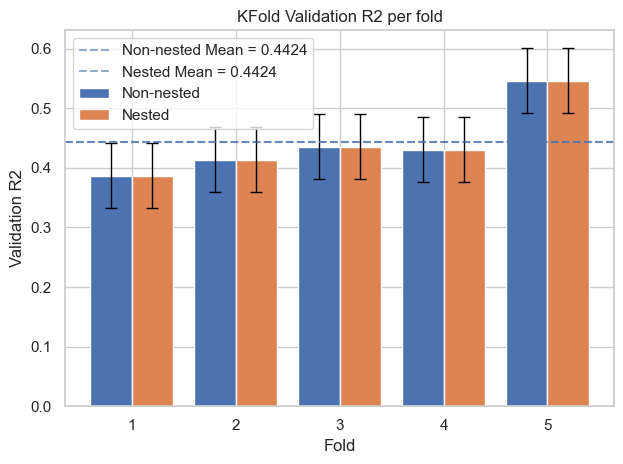

r2 TR vs VL from KFold Nested results


,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,0.578786,0.386671,-0.192115,33.19%
2,0.563854,0.413689,-0.150165,26.63%
3,0.569715,0.435266,-0.134448,23.60%
4,0.570082,0.430449,-0.139633,24.49%
5,0.547530,0.545903,-0.001626,0.30%
MEAN,0.565993,0.442396,-0.123597,21.64%
STD,0.011616,0.060903,0.071855,12.51%


In [26]:
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_result,"Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric} TR vs VL from KFold Nested results")
    display(cr.kfold_regression_table(nested_result, use=metric))

<h3>Bootstrap Variance</h3>

In [17]:
importlib.reload(cr)
bootstrap_samples = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}
# due to little discrepancy from nested and non nested runner, we use nested_runner in this case as it is faster and
# we are not in model selection activity
bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict, bootstrap_params=bootstrap_params)
cr.aggregate_scores(bootstrap_scores)

,metric,means,stds
0,r2,0.41,0.03
1,rmse,13.81,0.52
2,mee,23.94,0.89
3,mae,10.62,0.40
4,mse,191.00,14.33


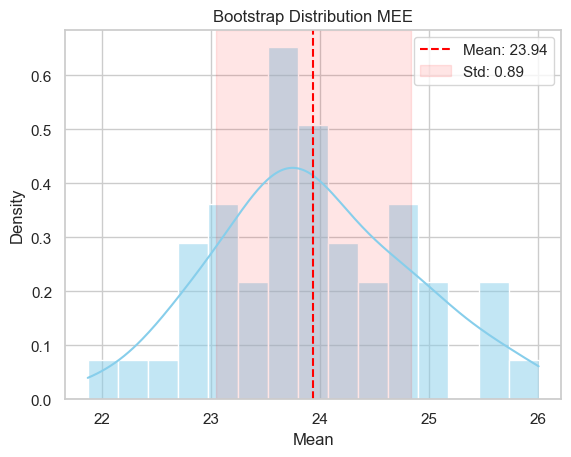

In [19]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title="Bootstrap Distribution MEE")

<h2>Test predictions</h2>
<hr/>

In [21]:
unfitted_model = non_nested_runner.new_model()
fitted_model = non_nested_runner.fit(unfitted_model, X_tr, y_tr)
y_pred = non_nested_runner.predict(fitted_model, X_ts)

In [22]:
print(y_pred)

[[ -2.38738272  -1.17794427   7.56084307  -4.05773067]
 [ -5.87534007   5.74615803 -33.7269309   22.6149831 ]
 [ -5.30597773  -9.73974222  -3.52607161   7.60003837]
 ...
 [ -3.61116456   3.63595657  21.36572376  -8.35175532]
 [  9.00688967  -0.98325326 -21.37452701  25.55960183]
 [ -2.30728735  -2.10446345   7.16022253  -2.22346679]]


<hr/>